In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, precision_recall_curve

from sklearn.metrics import roc_auc_score, classification_report, brier_score_loss, confusion_matrix, log_loss
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import shap
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight

/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# same code used for each dataset, just change the path
df = pd.read_csv("dmean_df.csv")
print(df.shape)

# df = pd.read_csv("dmax_df.csv")
# print(df.columns)
# print(df.shape)

Index(['ToothType', 'ExtractionFlag', 'TumorLaterality', 'TumorLocation',
       'TNM_T', 'TNM_N', 'TNM_Stage', 'TotalDose', 'Typetumor_cat',
       'Tumor_site', 'Stage', 'Systemic_therapy', 'StageItmIV'],
      dtype='object')
(1738, 13)


In [ ]:
# ensuring 80/20 split based on PatientID
y = df["ExtractionFlag"]
X = df.drop(columns=["ExtractionFlag"])

X_dummies = pd.get_dummies(
    X,
    columns=[c for c in X.columns if c not in ["TotalDose", "PatientID"]],
    drop_first=False,
    dtype=float
)

unique_patients = df['PatientID'].unique()

train_patients, test_patients = train_test_split(
    unique_patients, 
    test_size=0.2, 
    random_state=42
)

train_mask = df['PatientID'].isin(train_patients)
test_mask = df['PatientID'].isin(test_patients)

X_train = X_dummies[train_mask]
X_test = X_dummies[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

X_train = X_train.drop(columns=["PatientID"])
X_test = X_test.drop(columns=["PatientID"])

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Checking which kernel works best

In [ ]:
# linear
param_grid = {
    'C': [0.1, 1, 10],
    'class_weight': [
        'balanced',
        {0: 1, 1: 2},
        {0: 1, 1: 4}
    ]
}

svm_rbf = SVC(kernel='rbf', probability=False)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    svm_rbf,
    param_grid,
    cv=5,
    scoring='accuracy',  
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Best params and evaluation
print("\nBest Parameters:", grid_search.best_params_)
print("\nClassification Report (Test Set):")
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................C=0.1, class_weight={0: 1, 1: 2}; total time=   0.2s
[CV] END ...................C=0.1, class_weight={0: 1, 1: 2}; total time=   0.2s
[CV] END ...................C=0.1, class_weight={0: 1, 1: 2}; total time=   0.2s
[CV] END .......................C=0.1, class_weight=balanced; total time=   0.2s
[CV] END .......................C=0.1, class_weight=balanced; total time=   0.2s
[CV] END .......................C=0.1, class_weight=balanced; total time=   0.2s
[CV] END .......................C=0.1, class_weight=balanced; total time=   0.2s
[CV] END .......................C=0.1, class_weight=balanced; total time=   0.2s
[CV] END ...................C=0.1, class_weight={0: 1, 1: 4}; total time=   0.1s
[CV] END ...................C=0.1, class_weight={0: 1, 1: 2}; total time=   0.2s
[CV] END ...................C=0.1, class_weight={0: 1, 1: 4}; total time=   0.1s
[CV] END ...................C=0.1, class_weight={

In [ ]:
# parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'class_weight': [
        'balanced',
        {0: 1, 1: 2},
        {0: 1, 1: 4}
    ]
}

# Initialize SVC with RBF kernel
svm_rbf = SVC(kernel='rbf', probability=False, random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    svm_rbf,
    param_grid,
    cv=5,
    scoring='accuracy',  
    n_jobs=-1,
    verbose=2
)

# Fit model
grid_search.fit(X_train, y_train)
best_svc = grid_search.best_estimator_

# Best params and evaluation
print("\nBest Parameters:", grid_search.best_params_)
print("\nClassification Report (Test Set):")
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 45 candidates, totalling 225 fits
[CV] END ..........C=0.1, class_weight=balanced, gamma=scale; total time=   0.1s
[CV] END ..........C=0.1, class_weight=balanced, gamma=scale; total time=   0.1s
[CV] END ...........C=0.1, class_weight=balanced, gamma=auto; total time=   0.1s
[CV] END ..........C=0.1, class_weight=balanced, gamma=scale; total time=   0.1s
[CV] END ..........C=0.1, class_weight=balanced, gamma=scale; total time=   0.1s
[CV] END ..........C=0.1, class_weight=balanced, gamma=scale; total time=   0.1s
[CV] END ...........C=0.1, class_weight=balanced, gamma=auto; total time=   0.1s
[CV] END ...........C=0.1, class_weight=balanced, gamma=auto; total time=   0.1s
[CV] END ...........C=0.1, class_weight=balanced, gamma=auto; total time=   0.1s
[CV] END ...........C=0.1, class_weight=balanced, gamma=auto; total time=   0.1s
[CV] END ...........C=0.1, class_weight=balanced, gamma=0.01; total time=   0.1s
[CV] END ...........C=0.1, class_weight=balance

# Calibrating

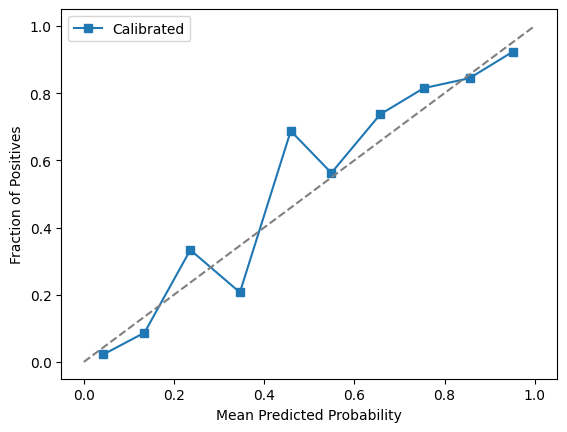

Calibrated   Brier: 0.11563057000761576
Calibrated   ROC AUC: 0.9124144210987826


In [ ]:
# Wrap & fit a sigmoid calibrator with 5-fold CV
calibrator = CalibratedClassifierCV(
    estimator=grid_search.best_estimator_, 
    cv=5,
    method='sigmoid'
)
calibrator.fit(X_train, y_train)

y_proba_cal = calibrator.predict_proba(X_test)[:, 1]
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)


# Calibration curves
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Calibrated')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

# Brier & ROC AUC
print("Calibrated   Brier:", brier_score_loss(y_test, y_proba_cal))
print("Calibrated   ROC AUC:", roc_auc_score(y_test, y_proba_cal))

In [ ]:
# Weighted cross-entropy 
classes = np.unique(y_test)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_test)
class_weight_dict = dict(zip(classes, cw))
sample_weights = np.array([class_weight_dict[y] for y in y_test])
wlog = log_loss(y_test, y_proba_cal, sample_weight=sample_weights)
print(f"Weighted log-loss: {wlog:.4f}")

# Confusion matrix & classification report at threshold=0.5
for thr in [0.5]:
    y_thr = (y_proba_cal >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_thr)
    print(f"\nThreshold={thr} Confusion Matrix:\n{cm_thr}")
    print(classification_report(y_test, y_thr))

Brier score: 0.1156
Weighted log-loss: 0.3823

Threshold=0.5 Confusion Matrix:
[[172  27]
 [ 30 119]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       199
           1       0.82      0.80      0.81       149

    accuracy                           0.84       348
   macro avg       0.83      0.83      0.83       348
weighted avg       0.84      0.84      0.84       348



/var/folders/8m/xsxvn0ns46dg_dpnlhpkxk6r0000gn/T/ipykernel_42147/170317349.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby('bin')['true'].value_counts().unstack().fillna(0)


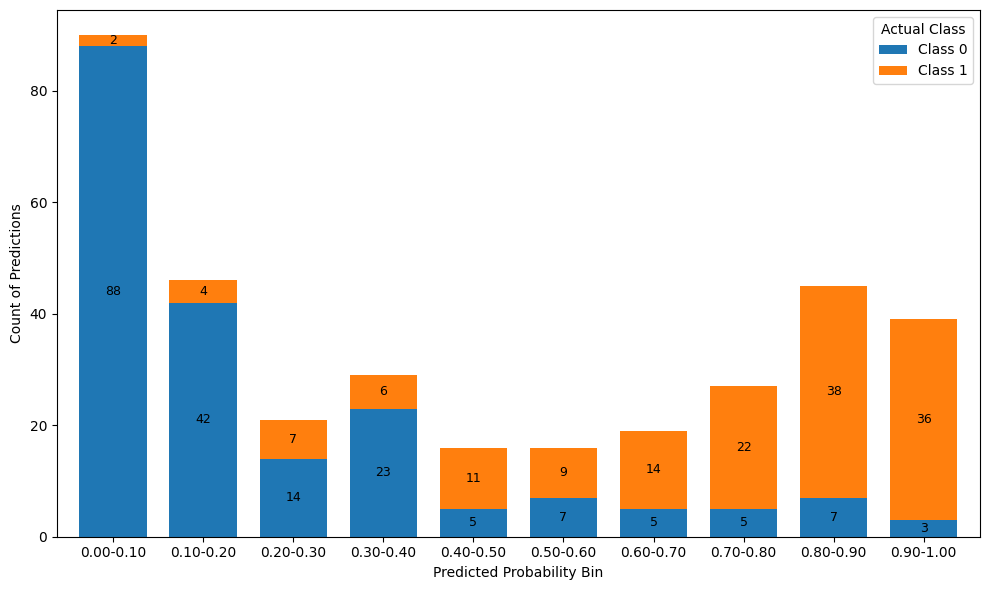

In [ ]:
bins = np.arange(0, 1.1, 0.1)
bin_labels = [f"{b:.2f}-{b+0.1:.2f}" for b in bins[:-1]]

df = pd.DataFrame({
    'prob': y_proba_cal,
    'true': y_test,
    'bin': pd.cut(y_proba_cal, bins=bins, labels=bin_labels, include_lowest=True)
})

counts = df.groupby('bin')['true'].value_counts().unstack().fillna(0)
counts.columns = ['Class 0', 'Class 1']

fig, ax = plt.subplots(figsize=(10, 6))    
counts.plot(kind='bar', 
            stacked=True, 
            ax=ax, 
            width=0.75)                  
# plt.title('Prediction Accuracy by Probability Bin (Calibrated)')
plt.xlabel('Predicted Probability Bin')
plt.ylabel('Count of Predictions')
plt.xticks(rotation=0)
plt.legend(title='Actual Class', loc='upper right')
plt.tight_layout()

# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.annotate(f'{int(height)}', 
                    (x + p.get_width()/2, y + height/2), 
                    ha='center', va='center', 
                    color='black', fontsize=9)

plt.show()

In [ ]:
def model_predict(X):
    """function that returns probabilities for positive class"""
    return calibrator.predict_proba(X)[:, 1]

# subset of training data as background (for efficiency)
background_size = min(150, len(X_train)) 
background_indices = np.random.choice(len(X_train), background_size, replace=False)
X_background = X_train.iloc[background_indices] if hasattr(X_train, 'iloc') else X_train[background_indices]

explainer = shap.KernelExplainer(model_predict, X_background)

# Select samples to explain 
n_explain = min(30, len(X_test))  
X_explain = X_test[:n_explain] if not hasattr(X_test, 'iloc') else X_test.iloc[:n_explain]

print(f"Explaining {n_explain} test samples using {background_size} background samples...")
print("This may take a few minutes...")

# Compute SHAP values
shap_values = explainer.shap_values(X_explain)

print(f"SHAP values computed! Shape: {shap_values.shape}")

In [ ]:
# Aggregate and rank feature importances
shap_df    = pd.DataFrame(shap_values, columns=X_train.columns)
mean_abs   = shap_df.abs().mean().sort_values(ascending=True)
top15      = mean_abs.nlargest(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind="barh")   
plt.title("DMean") # change to "DMax" if using dmax_df
plt.xlabel("Mean |SHAP value| ") # change to "Max |SHAP value|" if using dmax_df
plt.tight_layout()
plt.show()